In [156]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [365]:
grid_size = (200, 100) # x, y

In [366]:
yy, xx = torch.meshgrid(
    torch.arange(grid_size[1]),
    torch.arange(grid_size[0]))

In [367]:
yy.shape

torch.Size([100, 200])

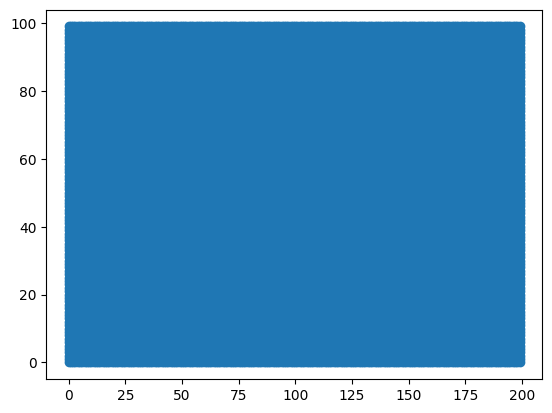

In [368]:
plt.scatter(xx, yy)

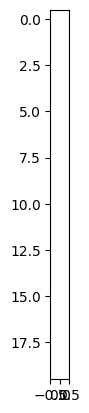

In [369]:
plt.imshow(canvas)

In [454]:
def draw(xp):
    canvas = torch.ones(*grid_size[::-1], 3)
    yp = 20
    size = 1
    dot_color = torch.tensor([0.,1.,0.])
    distance = torch.sqrt((xx - xp)**2 + (yy - yp)**2)
    mask = torch.sigmoid(size/2 - distance).unsqueeze(-1)

    return (mask * dot_color) + (1 - mask) * canvas

In [434]:
canvas_001 = draw(10)

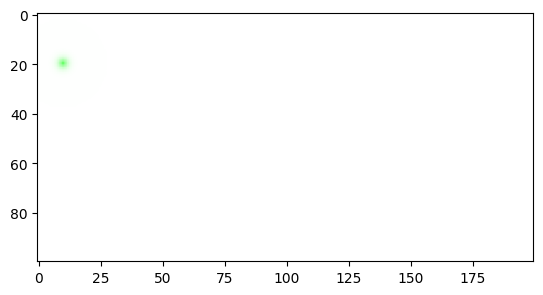

In [435]:
plt.imshow(canvas_001)

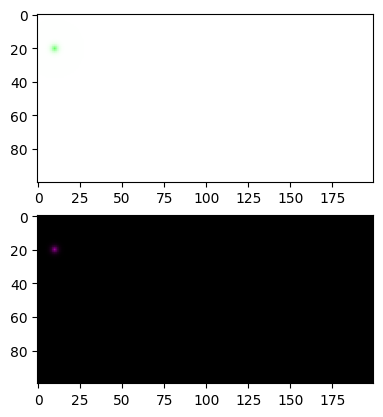

In [436]:
f, ax = plt.subplots(2,1)

ax[0].imshow(draw(10))
ax[1].imshow(1 - draw(10))

In [445]:
xp = torch.tensor(10.0, requires_grad=True)

In [446]:
draw_target = draw(20)

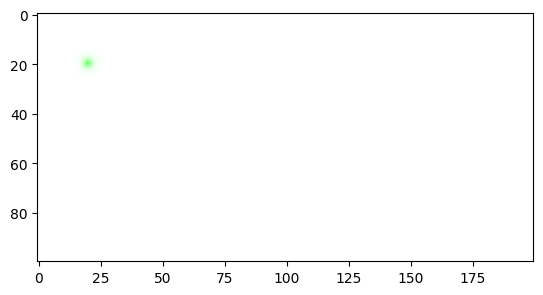

In [447]:
plt.imshow(draw_target)

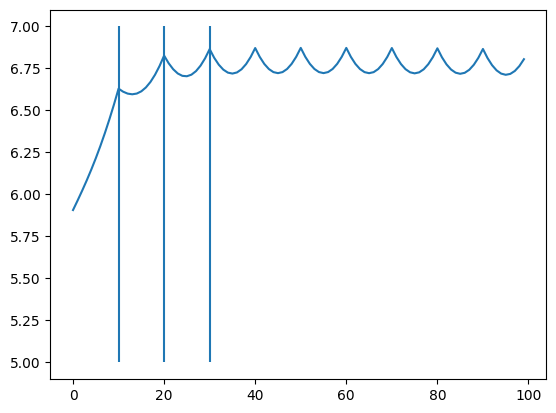

In [463]:
plt.plot([(draw(x/10) - draw_target).pow(2).sum() for x in range(100)])
plt.vlines([10, 20, 30], ymin=5, ymax=7)
#plt.scatter()

In [449]:
learning_rate = 1e-8
for t in range(2000):
    y_hat = draw(xp)
    loss = (y_hat - draw_target).pow(2).sum()
    if t % 1 == 0:
        print(f"{t} | loss: {loss} | grad: {xp.grad}")
    
    loss.backward()

    with torch.no_grad():
        xp -= learning_rate * xp.grad
        xp.grad = None

0 | loss: 6.857019424438477 | grad: None
1 | loss: nan | grad: None
2 | loss: nan | grad: None
3 | loss: nan | grad: None
4 | loss: nan | grad: None
5 | loss: nan | grad: None
6 | loss: nan | grad: None
7 | loss: nan | grad: None
8 | loss: nan | grad: None
9 | loss: nan | grad: None
10 | loss: nan | grad: None
11 | loss: nan | grad: None
12 | loss: nan | grad: None
13 | loss: nan | grad: None
14 | loss: nan | grad: None
15 | loss: nan | grad: None
16 | loss: nan | grad: None
17 | loss: nan | grad: None
18 | loss: nan | grad: None
19 | loss: nan | grad: None
20 | loss: nan | grad: None
21 | loss: nan | grad: None
22 | loss: nan | grad: None
23 | loss: nan | grad: None
24 | loss: nan | grad: None
25 | loss: nan | grad: None
26 | loss: nan | grad: None
27 | loss: nan | grad: None
28 | loss: nan | grad: None
29 | loss: nan | grad: None
30 | loss: nan | grad: None
31 | loss: nan | grad: None
32 | loss: nan | grad: None
33 | loss: nan | grad: None
34 | loss: nan | grad: None
35 | loss: nan |

In [417]:
xp

tensor(10., requires_grad=True)

In [262]:
(draw(50) - draw_target).pow(2).sum()

tensor(2.6452)

In [50]:
draw(20)

tensor([[[3.3771e-09],
         [9.1769e-09],
         [2.4936e-08],
         [6.7756e-08],
         [1.8410e-07],
         [5.0016e-07],
         [1.3588e-06],
         [3.6910e-06],
         [1.0025e-05],
         [2.7225e-05],
         [7.3917e-05],
         [2.0062e-04],
         [5.4422e-04],
         [1.4747e-03],
         [3.9867e-03],
         [1.0719e-02],
         [2.8439e-02],
         [7.3008e-02],
         [1.7342e-01],
         [3.5023e-01]]])